In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, SimpleRNN, Embedding, Flatten

In [2]:
(X_train,Y_train),(X_test,Y_test) = imdb.load_data(num_words=10000)

/home/midori/Desktop/Nural_Network/nural_venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [3]:
X_train.shape

(25000,)

In [4]:
X_train
# allready tokenized and converted to integers. Each integer represents a word in the review. 
# The reviews are already preprocessed and tokenized, so we can directly use them for training our model.

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [5]:
len(X_train[0])

218

In [6]:
len(X_train[1])

189

In [7]:
# finding the maximum length of review
max_len = max(len(X) for X in X_train)
max_len

2494

### padding

In [6]:
from tensorflow.keras.utils import pad_sequences

In [8]:
X_train = pad_sequences(X_train, padding='post', maxlen=50)
X_test = pad_sequences(X_test, padding='post', maxlen=50)

In [10]:
X_train.shape

(25000, 50)

In [11]:
X_train

array([[2071,   56,   26, ...,   19,  178,   32],
       [8255,    5,    2, ...,   16,  145,   95],
       [ 215,   28,  610, ...,    7,  129,  113],
       ...,
       [   4,   65,  496, ...,    4, 3586,    2],
       [  13,   18,   31, ...,   12,    9,   23],
       [7585,    8, 2197, ...,  204,  131,    9]],
      shape=(25000, 50), dtype=int32)

In [12]:
len(X_train[0])

50

### RNN

In [33]:
model1 = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=10000, output_dim=5),
    SimpleRNN(32, return_sequences=False),
    Dense(1, activation='sigmoid')
])
model1.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 50, 5)          │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_23 (SimpleRNN)       │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,249 (200.19 KB)

 Trainable params: 51,249 (200.19 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model1.fit(X_train, Y_train, epochs=10, validation_data=(X_test,Y_test), verbose=1)

Epoch 1/10


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.6256 - loss: 0.6152 - val_acc: 0.7741 - val_loss: 0.4900
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.8246 - loss: 0.3936 - val_acc: 0.7938 - val_loss: 0.4439
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.8755 - loss: 0.3033 - val_acc: 0.7972 - val_loss: 0.4461
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.9104 - loss: 0.2354 - val_acc: 0.7984 - val_loss: 0.4982
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.9369 - loss: 0.1758 - val_acc: 0.7832 - val_loss: 0.5711
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.9549 - loss: 0.1272 - val_acc: 0.7801 - val_loss: 0.6462
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.9673 - loss: 0.0983 - val_acc: 0.7808 - val_loss: 0.7633
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.9759 - loss: 0.0726 - val_acc: 0.7793 - val_loss: 0.9083
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.9820 -

In [30]:
import matplotlib.pyplot as plt

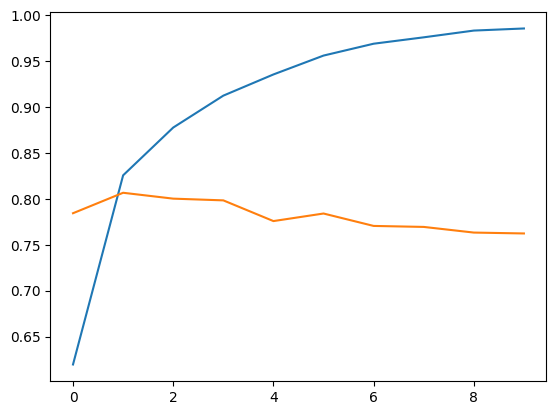

In [17]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

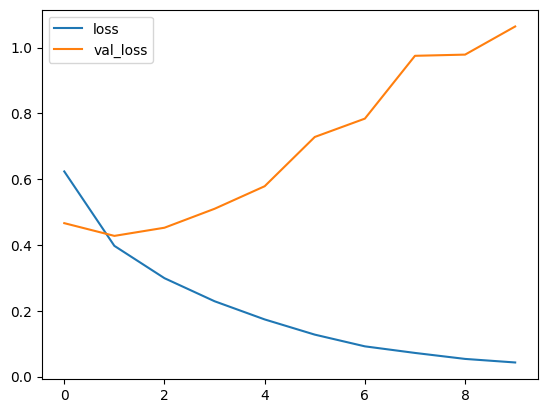

In [20]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

## using DEEP RNN 

In [62]:
model2 = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=10000, output_dim=5),
    SimpleRNN(25, return_sequences=True), # return_sequences=True to return the output of each time step to the next layer
    SimpleRNN(12),
    Dense(1, activation='sigmoid')
])
model2.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ (None, 50, 5)          │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_44 (SimpleRNN)       │ (None, 50, 25)         │           775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_45 (SimpleRNN)       │ (None, 12)             │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,244 (200.17 KB)

 Trainable params: 51,244 (200.17 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [64]:
history2 = model2.fit(X_train,Y_train, epochs=5, validation_data=(X_test,Y_test), verbose=1)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5598 - loss: 0.6702 - val_accuracy: 0.7415 - val_loss: 0.5371
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8088 - loss: 0.4218 - val_accuracy: 0.8057 - val_loss: 0.4246
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8810 - loss: 0.2934 - val_accuracy: 0.8012 - val_loss: 0.4534
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9267 - loss: 0.1965 - val_accuracy: 0.7874 - val_loss: 0.6008
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9546 - loss: 0.1341 - val_accuracy: 0.7871 - val_loss: 0.6435


## LSTM

In [67]:
from tensorflow.keras.layers import LSTM

In [85]:
model3 = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=10000, output_dim=5),
    LSTM(12, return_sequences=True),
    LSTM(5),
    Dense(1, activation='sigmoid')
])
model3.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_38 (Embedding)        │ (None, 50, 5)          │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 50, 12)         │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 5)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,230 (200.12 KB)

 Trainable params: 51,230 (200.12 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [87]:
history3 = model3.fit(X_train,Y_train, epochs=5, validation_data=(X_test,Y_test), verbose=1)

Epoch 1/5


782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7422 - loss: 0.5018 - val_accuracy: 0.8116 - val_loss: 0.4129
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8506 - loss: 0.3491 - val_accuracy: 0.8113 - val_loss: 0.4124
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8776 - loss: 0.2990 - val_accuracy: 0.8086 - val_loss: 0.4321
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8940 - loss: 0.2660 - val_accuracy: 0.8043 - val_loss: 0.4819
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9056 - loss: 0.2418 - val_accuracy: 0.7970 - val_loss: 0.4935


## GRU

In [89]:
from tensorflow.keras.layers import GRU

In [95]:
model4 = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=10000, output_dim=5),
    GRU(14, return_sequences=True),
    GRU(6),
    Dense(1, activation='sigmoid')
])
model4.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_44 (Embedding)        │ (None, 50, 5)          │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 50, 14)         │           882 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (None, 6)              │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,285 (200.33 KB)

 Trainable params: 51,285 (200.33 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [97]:
history4 = model4.fit(X_train,Y_train, epochs=5, validation_data=(X_test,Y_test), verbose=1)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.7434 - loss: 0.4972 - val_accuracy: 0.8086 - val_loss: 0.4161
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8486 - loss: 0.3459 - val_accuracy: 0.8022 - val_loss: 0.4313
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8780 - loss: 0.2949 - val_accuracy: 0.8101 - val_loss: 0.4329
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8946 - loss: 0.2641 - val_accuracy: 0.8026 - val_loss: 0.4626
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9047 - loss: 0.2435 - val_accuracy: 0.7996 - val_loss: 0.4811


## Bi-Directional RNN

In [16]:
from tensorflow.keras.layers import Bidirectional

In [17]:
model5 = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=10000, output_dim=5),
    Bidirectional(SimpleRNN(32)),
    Dense(1, activation='sigmoid')
])

In [18]:
model5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [19]:
model5.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 5)          │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,497 (205.07 KB)

 Trainable params: 52,497 (205.07 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history5 = model5.fit(X_train,Y_train,epochs=5, validation_data=(X_test,Y_test), verbose=1)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6052 - loss: 0.6353 - val_accuracy: 0.7838 - val_loss: 0.4669
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8201 - loss: 0.4036 - val_accuracy: 0.8052 - val_loss: 0.4261
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8716 - loss: 0.3112 - val_accuracy: 0.8073 - val_loss: 0.4461
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9027 - loss: 0.2462 - val_accuracy: 0.8009 - val_loss: 0.5076
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9290 - loss: 0.1907 - val_accuracy: 0.7827 - val_loss: 0.5952


## Result

In [ ]:
max_val_acc1 = max(history.history['val_acc'])
max_val_acc2 = max(history2.history['val_accuracy'])
max_val_acc3 = max(history3.history['val_accuracy'])
max_val_acc4 = max(history4.history['val_accuracy'])
max_val_acc5 = max(history5.history['val_accuracy'])

print('Keeping total number of parameters approximately same for all models\n')

print(f'Maximum validation accuracy using single RNN: {max_val_acc1:.4f}')
print(f'Maximum validation accuracy using deep RNN: {max_val_acc2:.4f}')
print(f'Maximum validation accuracy using deep LSTM: {max_val_acc3:.4f}')
print(f'Maximum validation accuracy using deep GRU: {max_val_acc4:.4f}')
print(f'Maximum validation accuracy using bi-directionalRNN: {max_val_acc5:.4f}')

In [ ]:
# Keeping total number of parameters approximately same for all models

# Maximum validation accuracy using single RNN: 0.7984
# Maximum validation accuracy using deep RNN: 0.8057
# Maximum validation accuracy using deep LSTM: 0.8116
# Maximum validation accuracy using deep GRU: 0.8101
# Maximum validation accuracy using bi-directionalRNN: 0.8073